In [1]:
# Importing the necessary libraries for the predictive model:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt

In [2]:
# Loading the csv files into Python
farmer_profiles = pd.read_csv(r"C:\Users\damid\Downloads\farmer_profiles.csv")
coldroom_profiles = pd.read_csv(r"C:\Users\damid\Downloads\coldroom_profiles.csv")
produce_listings = pd.read_csv(r"C:\Users\damid\Downloads\produce_listings.csv")
bookings = pd.read_csv(r"C:\Users\damid\Downloads\bookings.csv")
logistics_requests = pd.read_csv(r"C:\Users\damid\Downloads\logistics_requests.csv")
reviews = pd.read_csv(r"C:\Users\damid\Downloads\reviews.csv")

In [3]:
# Renaming the columns with figures in each table so as to make it easier to call them later on.
coldroom_profiles.rename(columns = {" price_per_tonne ": "price_per_tonne"}, inplace = True)
bookings.rename(columns = {" total_cost ": "total_cost"}, inplace = True)
produce_listings.rename(columns = {" price_per_kg ": "price_per_kg"}, inplace = True)
logistics_requests.rename(columns = {" estimated_cost ": "estimated_cost"}, inplace = True)

In [4]:
# Changing the data types of those columns, removing the naira sign (recognized as ? on python) as well as removing
# the commas and excess spacing in those columns.
coldroom_profiles["price_per_tonne"] = (
    coldroom_profiles["price_per_tonne"]
    .str.replace("?", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

bookings["total_cost"] = (
    bookings["total_cost"]
    .str.replace("?", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

produce_listings["price_per_kg"] = (
    produce_listings["price_per_kg"]
    .str.replace("?", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

logistics_requests["estimated_cost"] = (
    logistics_requests["estimated_cost"]
    .str.replace("?", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

In [5]:
# Converting pickup and delivery dates into date time so we can calculate how long
# a delivery took, and flag which ones were delayed
logistics_requests['pickup_date'] = pd.to_datetime(logistics_requests['pickup_date'])
logistics_requests['delivery_date'] = pd.to_datetime(logistics_requests['delivery_date'])
logistics_requests['transit_hours'] = (
    logistics_requests['delivery_date'] - logistics_requests['pickup_date']
).dt.total_seconds() / 3600

In [6]:
# Converting our start date and end date columns into date time so as to extract how many days products spend in
# storage
bookings['start_date'] = pd.to_datetime(bookings['start_date'])
bookings['end_date'] = pd.to_datetime(bookings['end_date'])
bookings['storage_duration_days'] = (bookings['end_date'] - bookings['start_date']).dt.days

In [7]:
# Converting harvest date and created date into date time so we can see how many
# days a batch waited before it was listed for sale
produce_listings['harvest_date'] = pd.to_datetime(produce_listings['harvest_date'])
produce_listings['created_at'] = pd.to_datetime(produce_listings['created_at'])
produce_listings['days_to_list'] = (
    produce_listings['created_at'] - produce_listings['harvest_date']
).dt.days

In [8]:
# Marking a batch as lost (1) only if it was graded Reject.
# This is the target our model will try to predict
produce_listings['is_loss'] = (produce_listings['quality_grade'] == 'Reject').astype(int)

In [9]:
# Grouping the bookings table by farmer so we get one row per farmer showing
# how they use coldroom storage
def most_used(x):
    if not x.mode().empty:
        return x.mode()[0]
    else:
        return None

farmer_booking_stats = bookings.groupby('farmer_id').agg(
    total_bookings=('id', 'count'),
    avg_storage_duration=('storage_duration_days', 'mean'),
    avg_booking_cost=('total_cost', 'mean'),
    most_used_coldroom=('coldroom_id', most_used)
).reset_index()

In [10]:
# Bringing in the details of each farmer's most used coldroom (like power source
# and rating) since that affects how safe their storage is
farmer_booking_stats = farmer_booking_stats.merge(
    coldroom_profiles[['id', 'power_source', 'price_per_tonne', 'rating']],
    left_on='most_used_coldroom', right_on='id', how='left'
).drop(columns=['id']).rename(columns={
    'power_source': 'coldroom_power_source',
    'price_per_tonne': 'coldroom_price',
    'rating': 'coldroom_rating'
})

In [11]:
# Linking logistics requests to farmers through bookings, then grouping by farmer
# to see their average transit time and how often deliveries are delayed
log_with_farmer = logistics_requests.merge(
    bookings[['id', 'farmer_id']], left_on='booking_id', right_on='id', how='left'
)

farmer_logistics_stats = log_with_farmer.groupby('farmer_id').agg(
    avg_transit_hours=('transit_hours', 'mean'),
    delayed_ratio=('status', lambda x: (x == 'Delayed').mean())
).reset_index()

In [12]:
# Grouping reviews by the farmer being reviewed, to get their average rating
# and how many reviews they have
farmer_review_stats = reviews.groupby('reviewed_user_id').agg(
    avg_rating=('rating', 'mean'),
    review_count=('id', 'count')
).reset_index().rename(columns={'reviewed_user_id': 'farmer_id'})

In [13]:
# Combining farmer info with their storage, logistics, and review stats,
# then attaching all of that to each produce listing
model_df = produce_listings.merge(
    farmer_profiles[['id', 'state', 'lga', 'crop_types']],
    left_on='farmer_id', right_on='id', how='left'
)
model_df = model_df.merge(farmer_booking_stats, on='farmer_id', how='left')
model_df = model_df.merge(farmer_logistics_stats, on='farmer_id', how='left')
model_df = model_df.merge(farmer_review_stats, on='farmer_id', how='left')

In [14]:
# Filling blanks left by the merges. A blank here means the farmer never booked
# storage or never got reviewed, so 0 is the correct value, not missing data
fill_zero_cols = ['total_bookings', 'avg_storage_duration', 'avg_booking_cost',
                   'avg_transit_hours', 'delayed_ratio', 'avg_rating', 'review_count']
model_df[fill_zero_cols] = model_df[fill_zero_cols].fillna(0)
model_df['coldroom_power_source'] = model_df['coldroom_power_source'].fillna('No Storage Used')

In [15]:
# Splitting our features into two groups: one about coldroom/storage,
# and one about delivery/transit, so we can measure each risk separately
# Added quantity, price_per_kg, and days_to_list since they may carry more signal
storage_features = ['total_bookings', 'avg_storage_duration', 'avg_booking_cost',
                     'coldroom_power_source', 'coldroom_price', 'coldroom_rating',
                     'quantity', 'price_per_kg', 'days_to_list']

transit_features = ['avg_transit_hours', 'delayed_ratio',
                     'quantity', 'price_per_kg', 'days_to_list']

y = model_df['is_loss']

In [16]:
# Turning the storage-related columns into numbers the model can use
X_storage = pd.get_dummies(model_df[storage_features], columns=['coldroom_power_source'], drop_first=True)

In [17]:
# The transit features are already numbers, so no encoding needed here
X_transit = model_df[transit_features]

In [18]:
# Splitting both feature sets the same way, so we can train and test fairly
X_storage_train, X_storage_test, y_train, y_test = train_test_split(
    X_storage, y, test_size=0.2, random_state=42, stratify=y
)
X_transit_train, X_transit_test, _, _ = train_test_split(
    X_transit, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
# Logistic Regression works better when numbers are on a similar scale,
# so we scale both feature sets
scaler_storage = StandardScaler()
X_storage_train_scaled = scaler_storage.fit_transform(X_storage_train)
X_storage_test_scaled = scaler_storage.transform(X_storage_test)

scaler_transit = StandardScaler()
X_transit_train_scaled = scaler_transit.fit_transform(X_transit_train)
X_transit_test_scaled = scaler_transit.transform(X_transit_test)

In [20]:
# Training one model to measure storage risk, and one to measure transit risk
# class_weight='balanced' forces the model to pay more attention to loss cases,
# since they're the smaller group in our data
storage_model = LogisticRegression(max_iter=1000, class_weight='balanced')
storage_model.fit(X_storage_train_scaled, y_train)

transit_model = LogisticRegression(max_iter=1000, class_weight='balanced')
transit_model.fit(X_transit_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
# Checking accuracy and other performance details for both models
for name, model, X_test_scaled in [('Storage Risk Model', storage_model, X_storage_test_scaled),
                                     ('Transit Risk Model', transit_model, X_transit_test_scaled)]:
    preds = model.predict(X_test_scaled)
    print(name)
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))
    print("-" * 40)

Storage Risk Model
Accuracy: 0.5171428571428571
              precision    recall  f1-score   support

           0       0.90      0.52      0.66       631
           1       0.10      0.48      0.16        69

    accuracy                           0.52       700
   macro avg       0.50      0.50      0.41       700
weighted avg       0.82      0.52      0.61       700

----------------------------------------
Transit Risk Model
Accuracy: 0.4928571428571429
              precision    recall  f1-score   support

           0       0.92      0.48      0.63       631
           1       0.11      0.59      0.19        69

    accuracy                           0.49       700
   macro avg       0.51      0.54      0.41       700
weighted avg       0.84      0.49      0.59       700

----------------------------------------


In [22]:
# ROC-AUC tells us how well the model ranks risk overall, not just its yes/no guesses.
# Closer to 1.0 is better, 0.5 means it's no better than guessing
storage_probs = storage_model.predict_proba(X_storage_test_scaled)[:, 1]
transit_probs = transit_model.predict_proba(X_transit_test_scaled)[:, 1]

print("Storage Risk Model ROC-AUC:", roc_auc_score(y_test, storage_probs))
print("Transit Risk Model ROC-AUC:", roc_auc_score(y_test, transit_probs))

Storage Risk Model ROC-AUC: 0.5121615103700131
Transit Risk Model ROC-AUC: 0.518087232136705


In [23]:
# Scaling the full dataset the same way we scaled the training data,
# then getting each model's risk percentage for every listing
X_storage_scaled = scaler_storage.transform(X_storage)
X_transit_scaled = scaler_transit.transform(X_transit)

model_df['storage_risk'] = storage_model.predict_proba(X_storage_scaled)[:, 1]
model_df['transit_risk'] = transit_model.predict_proba(X_transit_scaled)[:, 1]

In [24]:
# Averaging both risk scores by state to see which states need coldrooms,
# which need logistics support, and how urgent each need is
state_risk = model_df.groupby('state').agg(
    avg_storage_risk=('storage_risk', 'mean'),
    avg_transit_risk=('transit_risk', 'mean')
).sort_values('avg_storage_risk', ascending=False)

print(state_risk)

          avg_storage_risk  avg_transit_risk
state                                       
Sokoto            0.541872          0.509973
Nasarawa          0.518341          0.515731
Kano              0.512288          0.493671
Benue             0.494983          0.503630
Zamfara           0.490902          0.472389
Niger             0.486514          0.494106
Kebbi             0.472304          0.511795
Kaduna            0.471890          0.484852


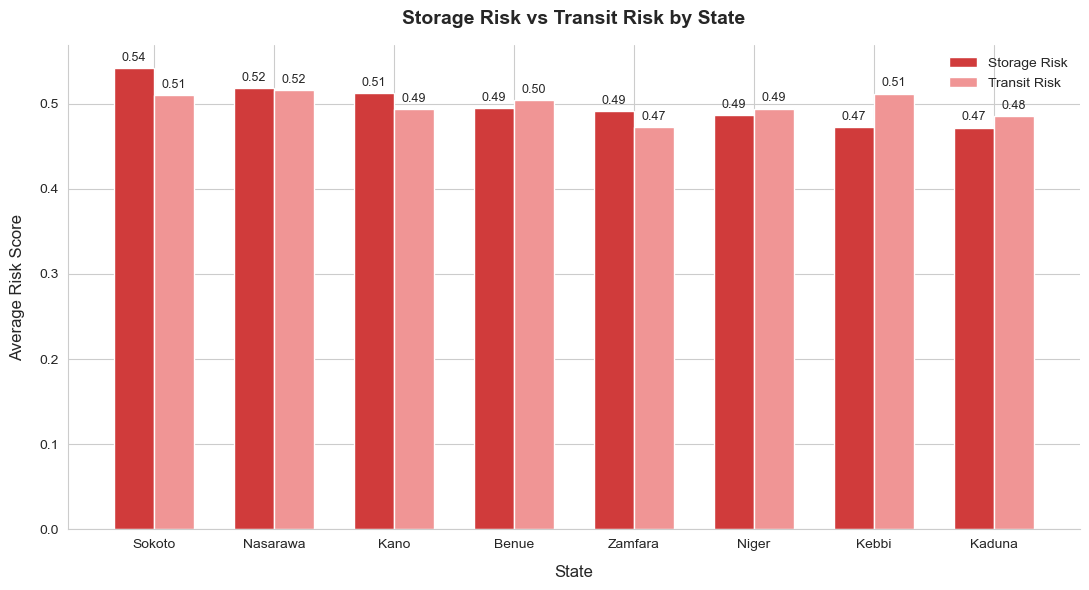

In [25]:
# Plotting a nicer looking bar chart with spacing between each state group
sns.set_style("whitegrid")

state_risk_sorted = state_risk.sort_values('avg_storage_risk', ascending=False)

x = np.arange(len(state_risk_sorted)) * 1.5
width = 0.5

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width/2, state_risk_sorted['avg_storage_risk'], width,
       label='Storage Risk', color='#D03B3B', edgecolor='white')
ax.bar(x + width/2, state_risk_sorted['avg_transit_risk'], width,
       label='Transit Risk', color='#F09595', edgecolor='white')

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)

ax.set_xlabel('State', fontsize=12, labelpad=10)
ax.set_ylabel('Average Risk Score', fontsize=12, labelpad=10)
ax.set_title('Storage Risk vs Transit Risk by State', fontsize=14, weight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(state_risk_sorted.index, rotation=0, fontsize=10)
ax.legend(frameon=False, fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [1]:
print("I shall take over the world")


I shall take over the world


In [ ]:
Damilare = "Patootie"
Timothy = "A Timothy"
Wilson = "Traitor"
Gabby = "Mwahhahhahahah"
Shalom = "Patootie Python" + "Ich bin nicht stressig, ich bin nur verspielt und ein bisschen schelmisch"Z
